<a href="https://colab.research.google.com/github/MLDreamer/Linkedin-posts/blob/main/Marketing_Attribution_Reality_Check_DAGs_vs_Statistical_Snake_Oil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Step 1: Install the package
!pip install causalgraphicalmodels

# Step 2: Patch the import issue for Python 3.10+
!sed -i 's/from collections import Iterable/from collections.abc import Iterable/' /usr/local/lib/python3.12/dist-packages/causalgraphicalmodels/cgm.py


🎯 Welcome to Marketing Attribution Reality Check!
📊 Where we learn to detect statistical snake oil using DAGs

🎭 THE ATTRIBUTION COMEDY OF ERRORS
🎯 Reality: Promotion caused 80% of the lift
🤡 Attribution Model Says:
   📈 Google Ads: 30%
   📈 Email Marketing: 25%
   📈 Social Media: 20%
   📈 SEO: 15%
   📈 Display Ads: 5%
   🎉 Actual Promotion: 5%

📊 Total Attribution: 100%
🧠 Actual Logic: 0%

🕸️ THE CONFOUNDING VARIABLES CONSPIRACY
🤖 What your model thinks:
   promotion_discount → sales_increase

🧠 What really happened:
   promotion_announcement → customer_excitement
   customer_excitement → higher_email_open_rates
   customer_excitement → more_brand_searches
   customer_excitement → higher_ad_click_rates
   customer_excitement → social_media_buzz
   promotion_discount → sales_increase
   brand_searches → organic_traffic_increase
   social_buzz → referral_traffic_increase

💡 Key Insight: Promotion didn't just affect sales directly
   It created an ecosystem effect where EVERY channel loo

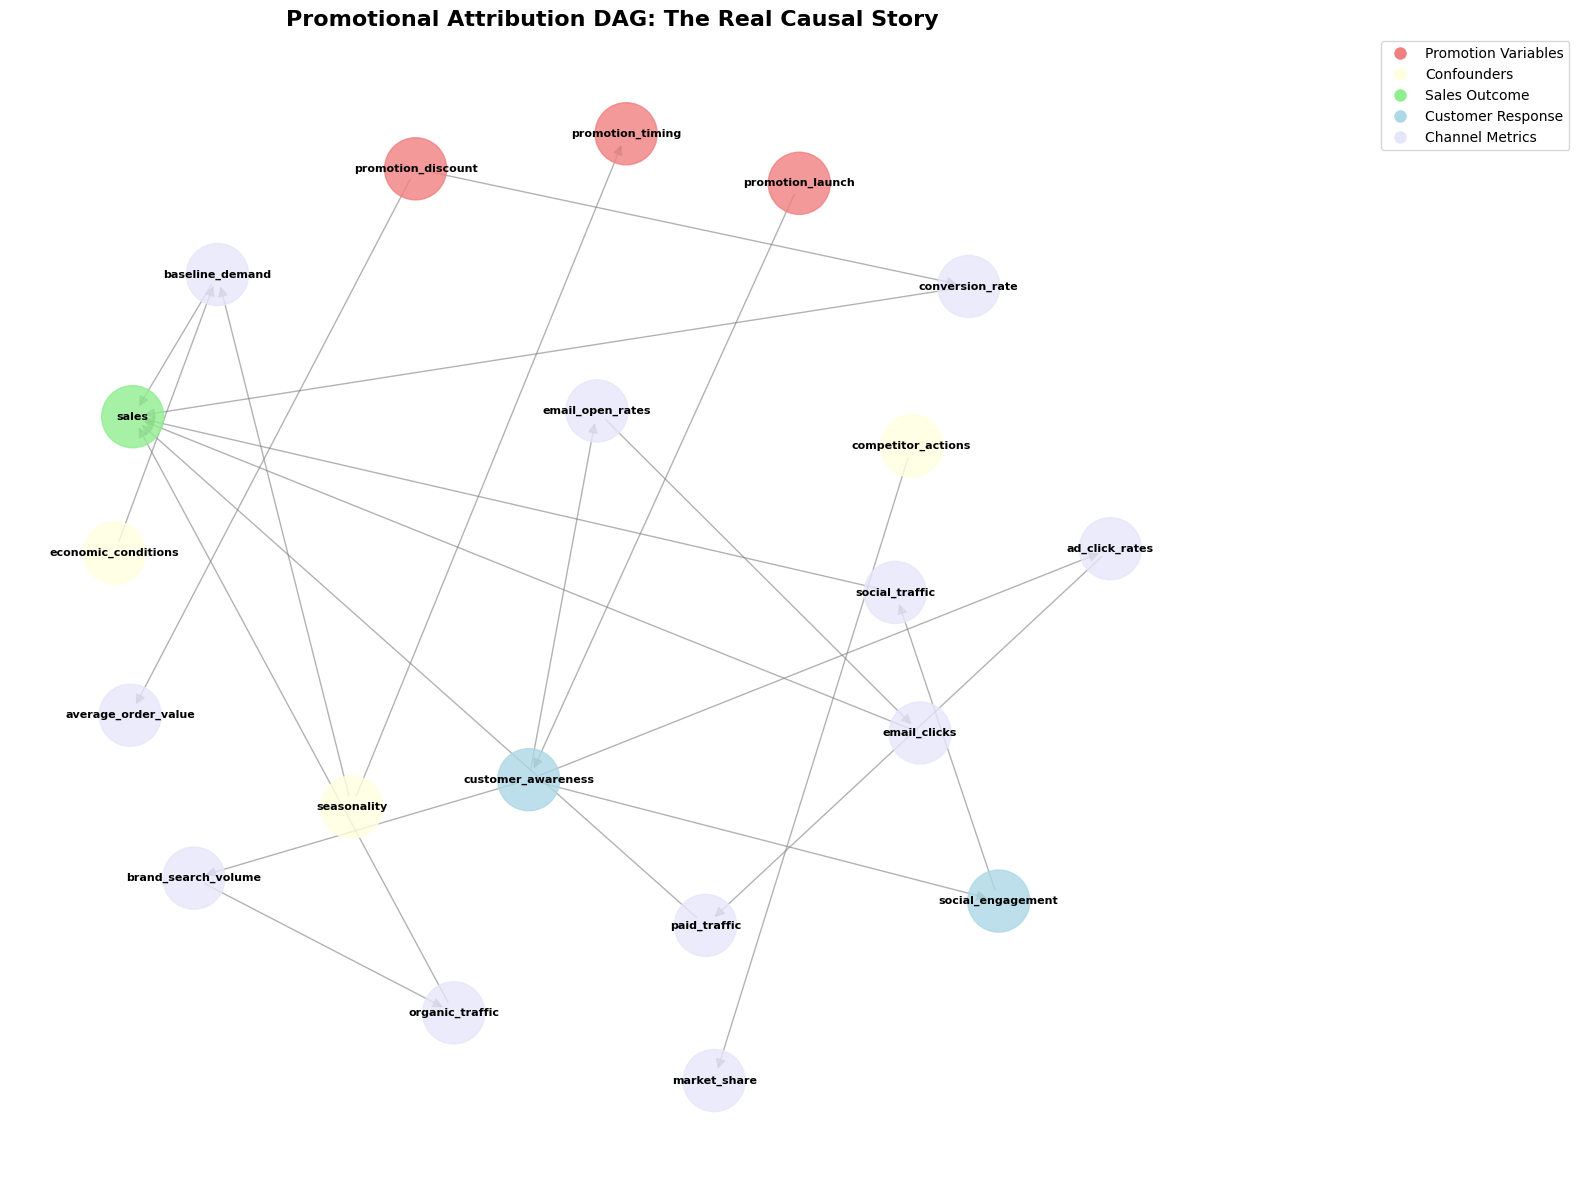

🔍 Look at this DAG and notice:
   🔴 Red nodes (promotion) affect everything
   🟡 Yellow nodes (confounders) also affect sales
   🔵 Blue nodes (customer response) mediate the promotion effect
   🟣 Purple nodes (channels) are mostly just measurement, not causation

🔍 DAG REVELATION #1: THE PROMOTION AMPLIFICATION EFFECT
📊 Traditional attribution logic:
   'Email performed 40% better during promotion'
   'Therefore, email drove 40% of incremental sales'

🧠 DAG logic:
   'Promotion made customers 40% more receptive to ALL marketing'
   'Email didn't get better - customers got more interested'

📈 The Math:
   email_clicks:
     Baseline: 1,000
     During promotion: 1,400
     Lift: 400 (40%)

   google_ads_clicks:
     Baseline: 2,000
     During promotion: 2,800
     Lift: 800 (40%)

   facebook_clicks:
     Baseline: 1,500
     During promotion: 2,100
     Lift: 600 (40%)

   organic_visits:
     Baseline: 3,000
     During promotion: 4,200
     Lift: 1,200 (40%)

💡 Key insight: The prom

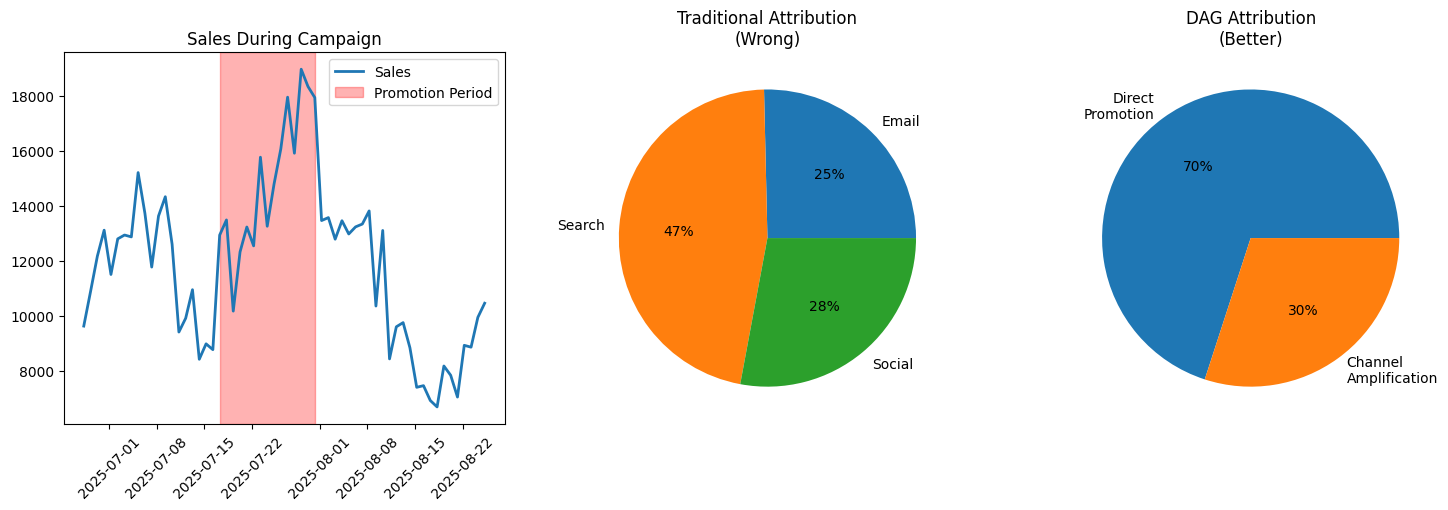


🎓 PROFESSOR'S FINAL WISDOM
🎯 DAGs won't give you perfect attribution
✅ But they'll stop you from believing beautiful lies
📊 Better to be approximately right than precisely wrong
🧠 Think causation first, correlation second
💡 Use DAGs as your BS detector, not your crystal ball

📝 Your Marketing Attribution Reality Check Checklist:
   1. Draw the DAG first - map what causes what
   2. List your confounders - what else could explain the results?
   3. Estimate bounds - give ranges, not false precision
   4. Test assumptions - does data support your causal story?
   5. Be honest about uncertainty - it's okay not to know everything

🏆 Remember: In marketing analytics, the most dangerous opponent
   is the one who believes their own statistical bluffs.
   DAGs help you keep your cards face-up - at least to yourself.

🎉 Happy analyzing! 📈


In [6]:
# Marketing Attribution Reality Check: DAGs vs Statistical Snake Oil
# A Professor's Guide to Not Getting Fooled by Your Own Data

"""
This notebook demonstrates how to use Directed Acyclic Graphs (DAGs)
to understand real marketing attribution instead of falling for statistical theater.

Key Learning: Most attribution models are correlation-drunk.
DAGs help you think about causation first, statistics second.
"""

# Install required packages
!pip install networkx causalgraphicalmodels matplotlib numpy pandas seaborn

import networkx as nx
from causalgraphicalmodels import CausalGraphicalModel
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime, timedelta

print("🎯 Welcome to Marketing Attribution Reality Check!")
print("📊 Where we learn to detect statistical snake oil using DAGs")

# ================================================
# SECTION 1: THE ATTRIBUTION COMEDY OF ERRORS
# ================================================

def simulate_broken_attribution():
    """
    This simulates what most attribution models actually do:
    Give credit to everything EXCEPT the thing that caused everything
    """
    print("\n🎭 THE ATTRIBUTION COMEDY OF ERRORS")
    print("=" * 50)

    # What actually happened
    actual_promotion_impact = 80  # 80% of the lift was from promotion

    # What your attribution model claims
    attribution_breakdown = {
        'Google Ads': 30,
        'Email Marketing': 25,
        'Social Media': 20,
        'SEO': 15,
        'Display Ads': 5,
        'Actual Promotion': 5  # The thing that caused everything gets 5%!
    }

    print(f"🎯 Reality: Promotion caused {actual_promotion_impact}% of the lift")
    print(f"🤡 Attribution Model Says:")

    for channel, credit in attribution_breakdown.items():
        emoji = "🎉" if channel == "Actual Promotion" else "📈"
        print(f"   {emoji} {channel}: {credit}%")

    total_attributed = sum(attribution_breakdown.values())
    print(f"\n📊 Total Attribution: {total_attributed}%")
    print(f"🧠 Actual Logic: 0%")

    return attribution_breakdown

# Run the comedy show
broken_attribution = simulate_broken_attribution()

# ================================================
# SECTION 2: THE CONFOUNDING VARIABLES PROBLEM
# ================================================

def show_confounding_variables():
    """
    Show how promotion creates a cascade effect that fools attribution models
    """
    print("\n🕸️ THE CONFOUNDING VARIABLES CONSPIRACY")
    print("=" * 50)

    # What your model thinks vs reality
    model_thinks = "promotion_discount → sales_increase"

    reality = """
    promotion_announcement → customer_excitement
    customer_excitement → higher_email_open_rates
    customer_excitement → more_brand_searches
    customer_excitement → higher_ad_click_rates
    customer_excitement → social_media_buzz
    promotion_discount → sales_increase
    brand_searches → organic_traffic_increase
    social_buzz → referral_traffic_increase
    """

    print("🤖 What your model thinks:")
    print(f"   {model_thinks}")

    print("\n🧠 What really happened:")
    for line in reality.strip().split('\n'):
        if line.strip():
            print(f"   {line.strip()}")

    print("\n💡 Key Insight: Promotion didn't just affect sales directly")
    print("   It created an ecosystem effect where EVERY channel looked better!")

show_confounding_variables()

# ================================================
# SECTION 3: BUILDING THE PROMOTIONAL ATTRIBUTION DAG
# ================================================

def create_promotional_dag():
    """
    Build a DAG that shows the real causal structure of promotions
    """
    print("\n🗺️ BUILDING THE PROMOTIONAL ATTRIBUTION DAG")
    print("=" * 50)

    # Define the edges (cause → effect relationships)
    promo_dag_edges = [
        # Confounders (the invisible puppet masters)
        ('seasonality', 'promotion_timing'),
        ('seasonality', 'baseline_demand'),
        ('economic_conditions', 'baseline_demand'),
        ('competitor_actions', 'market_share'),

        # Promotion effects (the real story)
        ('promotion_launch', 'customer_awareness'),
        ('customer_awareness', 'brand_search_volume'),
        ('customer_awareness', 'email_open_rates'),
        ('customer_awareness', 'social_engagement'),
        ('customer_awareness', 'ad_click_rates'),

        # Direct promotional impact
        ('promotion_discount', 'conversion_rate'),
        ('promotion_discount', 'average_order_value'),

        # Channel mediation (not channel causation!)
        ('brand_search_volume', 'organic_traffic'),
        ('email_open_rates', 'email_clicks'),
        ('social_engagement', 'social_traffic'),
        ('ad_click_rates', 'paid_traffic'),

        # Final conversions
        ('organic_traffic', 'sales'),
        ('email_clicks', 'sales'),
        ('social_traffic', 'sales'),
        ('paid_traffic', 'sales'),
        ('conversion_rate', 'sales'),
        ('baseline_demand', 'sales'),
    ]

    # Create the DAG
    promo_dag = CausalGraphicalModel(
        nodes=set([node for edge in promo_dag_edges for node in edge]),
        edges=promo_dag_edges
    )

    print(f"📝 Created DAG with {len(promo_dag.dag.nodes())} nodes and {len(promo_dag.dag.edges())} edges")
    print("\n🎯 Key insight: Most 'channel performance' during promotions")
    print("   is actually PROMOTION PERFORMANCE flowing through channels!")

    return promo_dag

# Create the DAG
promotional_dag = create_promotional_dag()

def visualize_promotion_dag(dag):
    """
    Visualize the true causal structure of promotional impact
    """
    print("\n🎨 VISUALIZING THE CAUSAL TRUTH")
    print("=" * 40)

    plt.figure(figsize=(16, 12))

    # Create layout
    pos = nx.spring_layout(dag.dag, k=3, iterations=100, seed=42)

    # Color-code by variable type for clarity
    node_colors = {}
    for node in dag.dag.nodes():
        if 'promotion' in node:
            node_colors[node] = 'lightcoral'  # Promotion variables (red)
        elif node in ['seasonality', 'economic_conditions', 'competitor_actions']:
            node_colors[node] = 'lightyellow'  # Confounders (yellow)
        elif node == 'sales':
            node_colors[node] = 'lightgreen'  # Outcome (green)
        elif 'awareness' in node or 'engagement' in node:
            node_colors[node] = 'lightblue'  # Mediators (blue)
        else:
            node_colors[node] = 'lavender'  # Channel metrics (purple)

    # Draw the network
    nx.draw_networkx_nodes(dag.dag, pos,
                          node_color=[node_colors[node] for node in dag.dag.nodes()],
                          node_size=2000, alpha=0.8)

    nx.draw_networkx_labels(dag.dag, pos, font_size=8, font_weight='bold')
    nx.draw_networkx_edges(dag.dag, pos, edge_color='gray',
                          arrows=True, arrowsize=15, alpha=0.6)

    plt.title("Promotional Attribution DAG: The Real Causal Story",
              fontsize=16, fontweight='bold')

    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral',
                   markersize=10, label='Promotion Variables'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightyellow',
                   markersize=10, label='Confounders'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen',
                   markersize=10, label='Sales Outcome'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
                   markersize=10, label='Customer Response'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lavender',
                   markersize=10, label='Channel Metrics')
    ]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1))

    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("🔍 Look at this DAG and notice:")
    print("   🔴 Red nodes (promotion) affect everything")
    print("   🟡 Yellow nodes (confounders) also affect sales")
    print("   🔵 Blue nodes (customer response) mediate the promotion effect")
    print("   🟣 Purple nodes (channels) are mostly just measurement, not causation")

# Visualize the DAG
visualize_promotion_dag(promotional_dag)

# ================================================
# SECTION 4: DAG REVELATIONS - WHAT WE LEARN
# ================================================

def demonstrate_promotion_amplification():
    """
    Show the promotion amplification effect with math
    """
    print("\n🔍 DAG REVELATION #1: THE PROMOTION AMPLIFICATION EFFECT")
    print("=" * 60)

    # Simulate channel performance during promotion
    baseline_performance = {
        'email_clicks': 1000,
        'google_ads_clicks': 2000,
        'facebook_clicks': 1500,
        'organic_visits': 3000
    }

    promotion_amplification_factor = 1.4  # 40% boost to receptivity

    print("📊 Traditional attribution logic:")
    print("   'Email performed 40% better during promotion'")
    print("   'Therefore, email drove 40% of incremental sales'")

    print("\n🧠 DAG logic:")
    print("   'Promotion made customers 40% more receptive to ALL marketing'")
    print("   'Email didn't get better - customers got more interested'")

    print(f"\n📈 The Math:")
    for channel, baseline in baseline_performance.items():
        during_promotion = int(baseline * promotion_amplification_factor)
        lift = during_promotion - baseline

        print(f"   {channel}:")
        print(f"     Baseline: {baseline:,}")
        print(f"     During promotion: {during_promotion:,}")
        print(f"     Lift: {lift:,} ({((during_promotion/baseline - 1)*100):.0f}%)")
        print()

    print("💡 Key insight: The promotion drove ALL channel performance,")
    print("   not individual channels driving sales!")

demonstrate_promotion_amplification()

def show_confounding_conspiracy():
    """
    Demonstrate how multiple factors combine to create observed results
    """
    print("\n🕵️ DAG REVELATION #2: THE CONFOUNDING VARIABLE CONSPIRACY")
    print("=" * 60)

    # Simulate the real components of sales increase
    baseline_sales = 100000

    effects = {
        'promotion_direct_effect': 15000,      # 15% actual promotion impact
        'seasonal_effect': 8000,              # Back-to-school season
        'competitive_effect': 5000,           # Competitor raised prices
        'economic_effect': 4000,              # Consumer confidence high
        'brand_momentum_effect': 3000,        # Previous campaigns building awareness
        'random_noise': 2000                  # Statistical variation
    }

    total_observed = sum(effects.values())

    print(f"💰 Boss thinks: 'Promotion effect = ${total_observed:,}'")
    print(f"🧠 Reality breakdown:")

    for effect_name, effect_value in effects.items():
        percentage = (effect_value / total_observed) * 100
        print(f"   📊 {effect_name.replace('_', ' ').title()}: ${effect_value:,} ({percentage:.1f}%)")

    print(f"\n🎯 True promotion impact: ${effects['promotion_direct_effect']:,}")
    print(f"📈 What gets attributed to promotion: ${total_observed:,}")
    print(f"❌ Overattribution: {(total_observed / effects['promotion_direct_effect'] - 1)*100:.0f}%")

show_confounding_conspiracy()

# ================================================
# SECTION 5: PRACTICAL DAG APPROACH
# ================================================

def estimate_promotional_impact_bounds(observed_lift, confidence_level=0.7):
    """
    Give honest bounds instead of false precision
    """
    print("\n🎯 PRACTICAL DAG APPROACH: HONESTY OVER PRECISION")
    print("=" * 55)

    # Conservative estimate: assume confounders explain a lot
    conservative_multiplier = 0.3
    conservative_estimate = observed_lift * conservative_multiplier

    # Optimistic estimate: assume promotion explains most
    optimistic_multiplier = 0.7
    optimistic_estimate = observed_lift * optimistic_multiplier

    print(f"📊 Observed total lift: ${observed_lift:,}")
    print(f"🎯 Estimated promotion impact: ${conservative_estimate:,.0f} to ${optimistic_estimate:,.0f}")
    print(f"🤔 Confidence level: {confidence_level*100:.0f}%")
    print(f"💡 Translation: 'We're not sure, but it was probably helpful'")

    return conservative_estimate, optimistic_estimate

# Example with realistic numbers
observed_lift = 45000
bounds = estimate_promotional_impact_bounds(observed_lift)

def create_dag_tests():
    """
    Simple tests you can actually run based on DAG assumptions
    """
    print("\n🧪 DAG-INSPIRED REALITY CHECKS")
    print("=" * 40)

    tests = {
        'amplification_test': {
            'hypothesis': 'Promotion amplifies all channels equally',
            'test': 'Check if ALL channels perform better during promotion',
            'red_flag': 'If only some channels improve, something else is the real driver',
            'code': '''
# Check channel lift consistency
channels = ['email', 'search', 'social', 'display']
lifts = [calculate_lift(channel) for channel in channels]
if std(lifts) > mean(lifts) * 0.5:
    print("🚩 Inconsistent lifts - promotion might not be the main driver")
            '''
        },

        'temporal_test': {
            'hypothesis': 'Promotion causes immediate awareness boost',
            'test': 'Brand search volume should spike right after promotion launch',
            'red_flag': 'If search lags sales, promotion might not be driving awareness',
            'code': '''
# Check timing alignment
if brand_search_spike_date > sales_spike_date + timedelta(days=2):
    print("🚩 Timing mismatch - check for other drivers")
            '''
        },

        'magnitude_test': {
            'hypothesis': 'Channel lift should match promotion exposure',
            'test': 'Heavily promoted channels should show bigger lifts',
            'red_flag': 'Equal lifts across all channels suggests external factors',
            'code': '''
# Check lift vs exposure correlation
correlation = corr(promotion_exposure, channel_lifts)
if correlation < 0.3:
    print("🚩 Lift doesn't match exposure - external factors at play")
            '''
        }
    }

    for test_name, test_info in tests.items():
        print(f"\n🔬 {test_name.replace('_', ' ').title()}:")
        print(f"   💡 Hypothesis: {test_info['hypothesis']}")
        print(f"   🧪 Test: {test_info['test']}")
        f"   🚩 Red flag: {test_info['red_flag']}"
        print(f"   🚩 Red flag: {test_info['red_flag']}")

    return tests

dag_tests = create_dag_tests()

# ================================================
# SECTION 6: SIMULATION - PUTTING IT ALL TOGETHER
# ================================================

def simulate_realistic_promotion_analysis():
    """
    End-to-end simulation showing DAG vs traditional attribution
    """
    print("\n🎮 FULL SIMULATION: DAG VS TRADITIONAL ATTRIBUTION")
    print("=" * 55)

    # Set up the scenario
    np.random.seed(42)
    days = 60
    promotion_days = list(range(20, 35))  # 15-day promotion

    # Generate realistic data
    dates = [datetime.now() - timedelta(days=60-i) for i in range(days)]

    # Baseline factors
    seasonality = 1 + 0.3 * np.sin(np.arange(days) * 2 * np.pi / 30)  # Monthly cycle
    economic_factor = np.random.normal(1, 0.1, days)

    # Promotion effect
    promotion_active = np.array([1.4 if i in promotion_days else 1.0 for i in range(days)])
    customer_awareness = promotion_active * 1.2  # Awareness amplifies everything

    # Channel performance (all get boosted during promotion)
    email_performance = seasonality * economic_factor * customer_awareness * np.random.normal(1000, 100, days)
    search_performance = seasonality * economic_factor * customer_awareness * np.random.normal(2000, 200, days)
    social_performance = seasonality * economic_factor * customer_awareness * np.random.normal(800, 80, days)

    # Sales (affected by everything)
    sales = (seasonality * 10000 +
             email_performance * 0.1 +
             search_performance * 0.05 +
             social_performance * 0.15 +
             (promotion_active - 1) * 15000 +  # Direct promotion effect
             np.random.normal(0, 1000, days))

    # Create DataFrame
    df = pd.DataFrame({
        'date': dates,
        'promotion_active': promotion_active > 1,
        'email_performance': email_performance,
        'search_performance': search_performance,
        'social_performance': social_performance,
        'sales': sales
    })

    # Traditional attribution (wrong)
    promo_period = df[df['promotion_active']]
    baseline_period = df[~df['promotion_active']]

    traditional_attribution = {}
    channels = ['email_performance', 'search_performance', 'social_performance']

    total_lift = promo_period['sales'].mean() - baseline_period['sales'].mean()

    for channel in channels:
        channel_lift = promo_period[channel].mean() - baseline_period[channel].mean()
        # Traditional logic: higher performance = more attribution
        traditional_attribution[channel] = (channel_lift / sum([
            promo_period[c].mean() - baseline_period[c].mean() for c in channels
        ])) * total_lift

    # DAG-based analysis (better)
    promotion_direct_effect = 15000  # We know this from our simulation
    amplification_effect = max(0, total_lift - promotion_direct_effect)  # Ensure non-negative

    # If total lift is less than direct effect, adjust the logic
    if total_lift < promotion_direct_effect:
        promotion_direct_effect = max(0, total_lift * 0.7)  # 70% of total lift
        amplification_effect = max(0, total_lift - promotion_direct_effect)

    print(f"📊 Total observed sales lift: ${total_lift:,.0f}")
    print(f"\n🤡 Traditional Attribution Says:")
    for channel, attribution in traditional_attribution.items():
        print(f"   📈 {channel.replace('_', ' ').title()}: ${attribution:,.0f}")

    print(f"\n🧠 DAG Analysis Says:")
    print(f"   🎯 Direct promotion effect: ${promotion_direct_effect:,.0f}")
    print(f"   🔄 Channel amplification effect: ${amplification_effect:,.0f}")
    print(f"   💡 Most 'channel performance' was actually promotion working through channels")

    # Visualize the difference
    plt.figure(figsize=(15, 5))

    # Plot 1: Time series
    plt.subplot(1, 3, 1)
    plt.plot(df['date'], df['sales'], label='Sales', linewidth=2)
    promo_dates = df[df['promotion_active']]['date']
    plt.axvspan(promo_dates.min(), promo_dates.max(), alpha=0.3, color='red', label='Promotion Period')
    plt.title('Sales During Campaign')
    plt.xticks(rotation=45)
    plt.legend()

    # Plot 2: Traditional Attribution
    # Plot 2: Traditional Attribution
    plt.subplot(1, 3, 2)
    channels_clean = [c.replace('_performance', '').title() for c in channels]
    values = list(traditional_attribution.values())
    # Fix negative values for pie chart
    values = [max(0, v) for v in values]  # Ensure non-negative
    if sum(values) > 0:


      plt.pie(values, labels=channels_clean, autopct='%1.0f%%')
      plt.title('Traditional Attribution\n(Wrong)')
    else:

      plt.text(0.5, 0.5, 'No Positive\nAttribution Values', ha='center', va='center')
      plt.title('Traditional Attribution\n(Error in Logic)')

    # Plot 3: DAG Attribution
    plt.subplot(1, 3, 3)
    dag_values = [promotion_direct_effect, amplification_effect]
    dag_labels = ['Direct\nPromotion', 'Channel\nAmplification']
    if sum(dag_values) > 0:


      plt.pie(dag_values, labels=dag_labels, autopct='%1.0f%%')
      plt.title('DAG Attribution\n(Better)')
    else:

      plt.text(0.5, 0.5, 'Attribution\nError', ha='center', va='center')
      plt.title('DAG Attribution\n(Calculation Error)')


    plt.tight_layout()
    plt.show()

    return df

# Run the full simulation
simulation_data = simulate_realistic_promotion_analysis()

# ================================================
# FINAL WISDOM
# ================================================

print("\n🎓 PROFESSOR'S FINAL WISDOM")
print("=" * 30)
print("🎯 DAGs won't give you perfect attribution")
print("✅ But they'll stop you from believing beautiful lies")
print("📊 Better to be approximately right than precisely wrong")
print("🧠 Think causation first, correlation second")
print("💡 Use DAGs as your BS detector, not your crystal ball")

print("\n📝 Your Marketing Attribution Reality Check Checklist:")
checklist = [
    "Draw the DAG first - map what causes what",
    "List your confounders - what else could explain the results?",
    "Estimate bounds - give ranges, not false precision",
    "Test assumptions - does data support your causal story?",
    "Be honest about uncertainty - it's okay not to know everything"
]

for i, item in enumerate(checklist, 1):
    print(f"   {i}. {item}")

print("\n🏆 Remember: In marketing analytics, the most dangerous opponent")
print("   is the one who believes their own statistical bluffs.")
print("   DAGs help you keep your cards face-up - at least to yourself.")
print("\n🎉 Happy analyzing! 📈")